# **What is a Decision Tree**

A decision tree is a tree-like model: internal nodes represent decisions based on features, branches represent outcomes of those decisions, leaves represent final class labels.

It works by recursively splitting the dataset into subsets until a stopping condition.

It’s non-parametric (doesn’t assume a specific distribution) and is easier to interpret than many “black-box” models.

# **How it Works (Attribute-Selection Measures)**

You must decide where to split. Common criteria:


*   Information Gain: reduction in entropy from a split.
*   Gain Ratio: a normalized version of information gain to reduce bias.
*   Gini Index: used by the CART algorithm; measures impurity.

When building a tree:

1.   Choose the best attribute (feature) to split on (via one of the measures).
2.   Split the data into subsets based on that attribute’s values or threshold.
3.   Repeat recursively for each subset until:

    *   All instances in a node belong to the same class.
    *   There are no remaining features.
    *   Or other stopping criteria (e.g., minimal samples).

















In [ ]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation

from google.colab import files
upload = files.upload()

Saving diabetes.csv to diabetes (2).csv


In [ ]:
# This line defines a list of column names. These are used to label
# each column in the dataset manually.
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

# load dataset
# -> header=0: tells pandas that the first row of the CSV file
# contains column names.
# -> names=col_names: tells pandas to replace whatever header is in
# the file with the ones you manually provided
pima = pd.read_csv("diabetes.csv", header=0, names=col_names)
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# split dataset in features and target variable
# -> these seven columns are the inputs (independent variables).
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp',
                'pedigree']
# -> extracts those specific columns from the dataframe pima and
# stores them in a new dataframe X and will be used as the input to
# train the model.
X = pima[feature_cols] # Features
# -> the outcome or class you want to predict
y = pima.label # Target variable

In [ ]:
# Split dataset into training set and test set
# 70% training and 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1)

# **Building Decision Tree Model**
Let's create a decision tree model using Scikit-learn.

In [ ]:
# Create Decision Tree Classifer object
# -> This line creates the model (an empty decision tree).
# -> By default, it uses the Gini index to decide how to split nodes.
# -> At this point, clf is only a model blueprint — it has not
# learned anything yet.
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
# -> .fit() trains the model using your training data.
# -> After this step, the tree has learned the patterns and is now
# a trained model.
clf = clf.fit(X_train,y_train)

# Predict the response for test dataset
# -> .predict() uses the trained model to make predictions on new,
# unseen data (X_test).
y_pred = clf.predict(X_test)

# y_pred now contains predicted labels for X_test

# **Evaluating the Model**
Let's estimate how accurately the classifier or model can predict the type of cultivars.

Accuracy can be computed by comparing actual test set values and predicted values.

In [ ]:
# Model Accuracy, how often is the classifier correct?
# -> It counts how many predictions were correct, divides by the
# total number of predictions, and returns a value between 0 and 1.
print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.6753246753246753


# **Visualizing Decision Trees**
You can use Scikit-learn's export_graphviz function for display the tree within a Jupyter notebook. For plotting the tree, you also need to install graphviz and pydotplus.

In [ ]:
!pip install graphviz
!pip install pydotplus

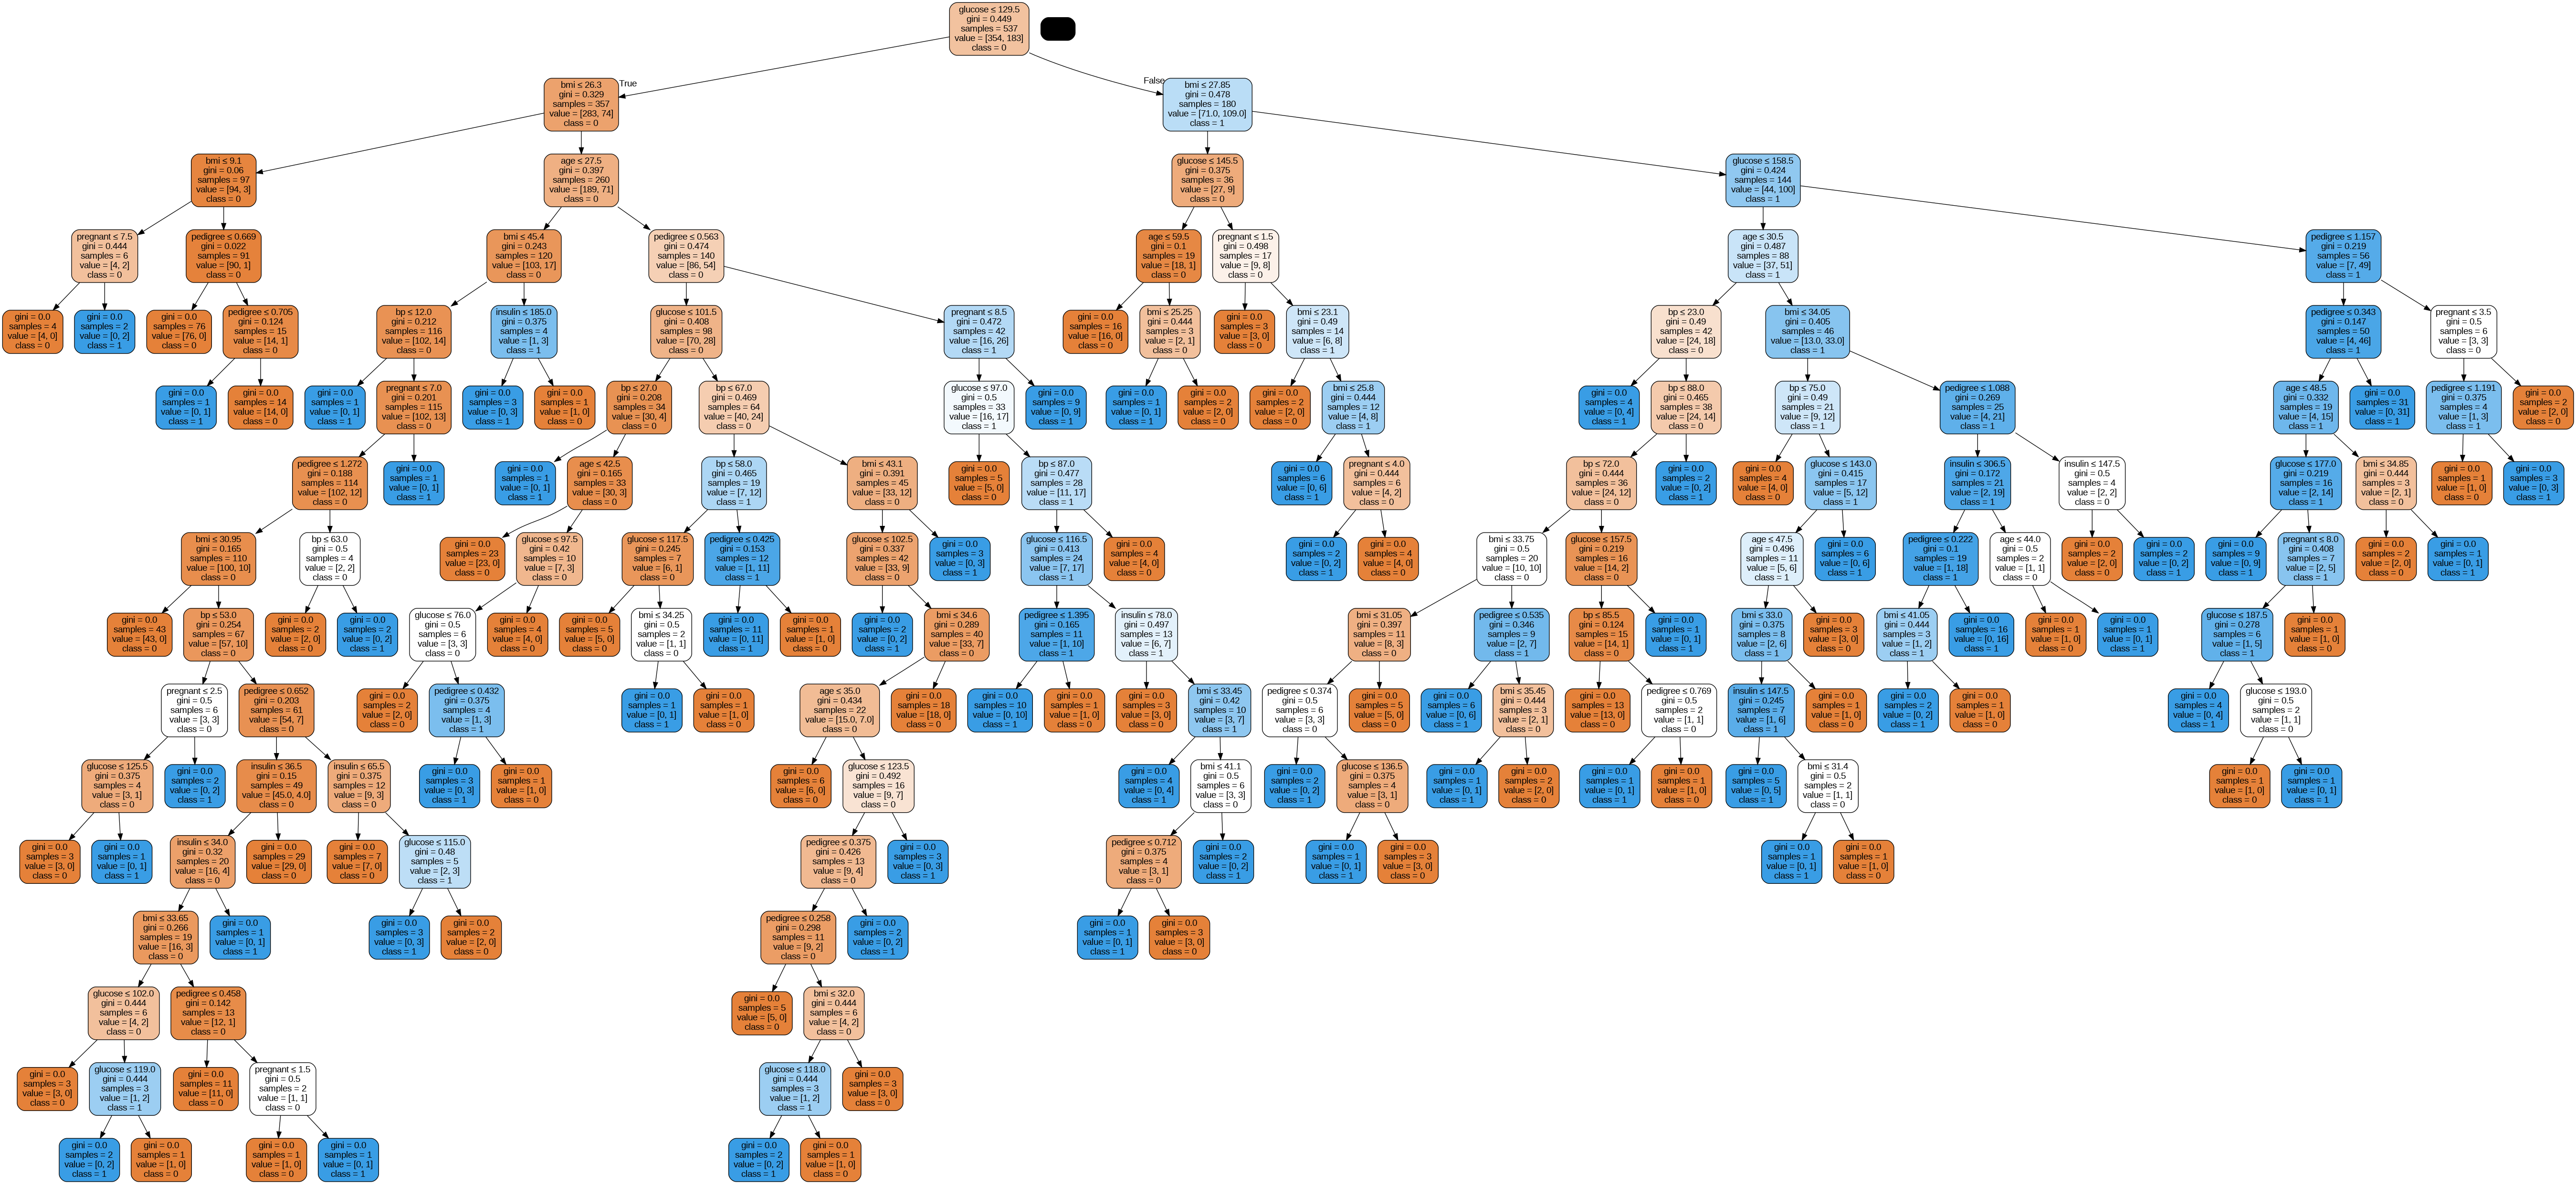

In [ ]:
# export_graphviz: Converts the trained decision tree into a
# Graphviz format so it can be visualized.
from sklearn.tree import export_graphviz
# StringIO: A memory buffer that behaves like a file. It stores the
# exported data temporarily in memory.
from io import StringIO
# Image: Displays the resulting tree image directly in your notebook.
from IPython.display import Image
# pydotplus: Converts the Graphviz data into an actual image (PNG format).
import pydotplus

# Creates a new in-memory text buffer to hold the .dot data
# generated by export_graphviz.
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data, # clf: the trained decision tree model. out_file=dot_data: writes the tree structure into the dot_data buffer.
                filled=True, rounded=True, # filled=True: fills each node with color based on its class or value. rounded=True: gives nodes rounded corners (for better readability).
                special_characters=True,feature_names = feature_cols, # special_characters=True: avoids display issues for special characters. feature_names=feature_cols: labels each node with the feature names used in the tree.
                class_names=['0','1']) # class_names=['0','1']: sets labels for the output classes (for example, 0 = no diabetes, 1 = diabetes).
# Takes the .dot data from memory (dot_data.getvalue()) and
# converts it into a graph object that can be turned into an image.
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
# Saves the decision tree image as a PNG file named diabetes.png
# in your working directory.
graph.write_png('diabetes.png')
# Displays the image directly inside your notebook
# (useful when you’re running this in Jupyter or Google Colab).
Image(graph.create_png())

# **Optimizing Decision Tree Performance**



*   criterion : optional (default=”gini”) or Choose attribute selection measure. This parameter allows us to use the different-different attribute selection measure. Supported criteria are “gini” for the Gini index and “entropy” for the information gain.
*   splitter : string, optional (default=”best”) or Split Strategy. This parameter allows us to choose the split strategy. Supported strategies are “best” to choose the best split and “random” to choose the best random split.
*   max_depth : int or None, optional (default=None) or Maximum Depth of a Tree. The maximum depth of the tree. If None, then nodes are expanded until all the leaves contain less than min_samples_split samples. The higher value of maximum depth causes overfitting, and a lower value causes underfitting (Source).





In [ ]:
# Create Decision Tree Classifer object
# -> criterion="entropy" means it will use information gain to
# decide where to split the data. (The other option is "gini".)
# -> max_depth=3 limits the tree to three levels. This helps prevent
# overfitting — when the tree learns noise instead of real patterns.
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

# Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.7705627705627706


Well, the classification rate increased to 77.05%, which is better accuracy than the previous model.

# **Visualizing Decision Trees**
Let's make our decision tree a little easier to understand using the following code:

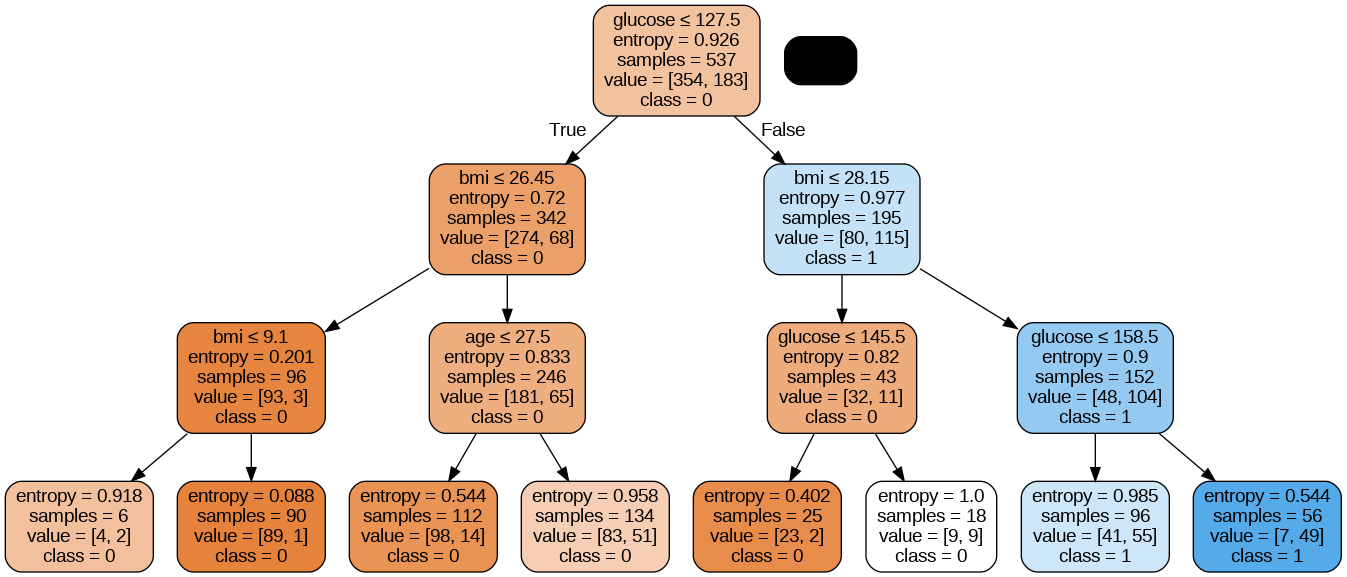

In [ ]:
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data, # clf: the trained decision tree model. out_file=dot_data: writes the tree structure into the dot_data buffer.
                filled=True, rounded=True, # filled=True: fills each node with color based on its class or value. rounded=True: gives nodes rounded corners (for better readability).
                special_characters=True,feature_names = feature_cols, # special_characters=True: avoids display issues for special characters. feature_names=feature_cols: labels each node with the feature names used in the tree.
                class_names=['0','1']) # class_names=['0','1']: sets labels for the output classes (for example, 0 = no diabetes, 1 = diabetes).
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

As you can see, this pruned model is less complex, more explainable, and easier to understand than the previous decision tree model plot.

# **Decision Tree Pros**

*   Decision trees are easy to interpret and visualize.
*   It can easily capture Non-linear patterns.
*   It requires fewer data preprocessing from the user, for example, there is no need to normalize columns.
*   It can be used for feature engineering such as predicting missing values, suitable for variable selection.
*   The decision tree has no assumptions about distribution because of the non-parametric nature of the algorithm. (Source)




# **Decision Tree Cons**

*   Sensitive to noisy data. It can overfit noisy data.
*   The small variation(or variance) in data can result in the different decision tree. This can be reduced by bagging and boosting algorithms.
*   Decision trees are biased with imbalance dataset, so it is recommended that balance out the dataset before creating the decision tree.

